# Check correlations with admission numbers

Check how well various types of data correlate when the full dataset is stratified by Index of Multiple Deprivation.

The correlations plotted from the full dataset can show more scatter than is ideal. By plotting only a subset of MSOA that have an IMD score within a particular ranges, the scatter is reduced and the correlation between the other two variables becomes tighter.

Although we don't have the information of how many admissions come from patients in each age band, we can see whether a higher number of patients in a group is associated with a higher number of admissions in an MSOA.


__Method:__

Check the following:
+ admissions vs age:
  + number of admissions vs number of people in each age band
  + proportion of admissions vs proportion of people in each age band

"Proportion of admissions" means the ratio of number of admissions to total population of the MSOA.

Check the correlations by visually inspecting scatter plots. Also fit linear regression and calculate the r-squared of the results.

__Conclusion:__
+ MSOAs with high levels of deprivation and few people can have as many stroke admissions as MSOAs with low levels of deprivation and lots of people, so stroke risk increases with deprivation.
+ The number of stroke admissions increases with increasing number or proportion of people in the older age groups (age 65-70 and upwards). There is less clear a correlation between admissions and number of people under 65.

## Code setup

In [1]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

from IPython.display import Image, display  # to display images from file

## Load data

Patient demographics by MSOA:

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [3]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Calculate proportion of admissions:

In [4]:
df_stats = df_stats.with_columns((pl.col('admissions') / pl.col('All persons')).alias('prop_admissions'))

In [5]:
df_stats.columns

['MSOA',
 'admissions',
 'IMD2019Score',
 'All persons',
 'country',
 'good_health',
 'fair health',
 'bad health',
 'prop_good_health',
 'prop_fair health',
 'prop_bad health',
 'MSOA11CD',
 'age_65_proportion',
 'age_70_proportion',
 'age_75_proportion',
 'age_less65_proportion',
 'age_over80_proportion',
 'total_health',
 'age_less65',
 'age_65',
 'age_70',
 'age_75',
 'age_over80',
 'depriv_quantile_min',
 'depriv_quantile_max',
 'prop_admissions']

In [6]:
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = ['age_less65_proportion', 'age_65_proportion', 'age_70_proportion', 'age_75_proportion', 'age_over80_proportion']
age_numbers = [p.replace('_proportion', '') for p in props_age]

In [7]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

qmin_list

[0.0, 0.2, 0.4, 0.6, 0.8]

Define colours for plotting:

In [8]:
colour_list = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(qmin_list)))

colour_dict = dict(zip(qmin_list, colour_list))

Define labels for plotting:

In [9]:
dict_q_labels = {}

for qmin in qmin_list:
    qmax = qmin + 0.2
    label = f'{qmin:.0%} to {qmax:.0%}'
    dict_q_labels[qmin] = label

dict_q_labels[0.0] = dict_q_labels[0.0] + ' (most deprived)'
dict_q_labels[0.8] = dict_q_labels[0.8] + ' (least deprived)'

dict_q_labels

{0.0: '0% to 20% (most deprived)',
 0.2: '20% to 40%',
 0.4: '40% to 60%',
 0.6: '60% to 80%',
 0.8: '80% to 100% (least deprived)'}

## Admissions vs age

Age vs admissions by IMD, again split over two figs:

In [10]:
# props_age = ['age_less65_proportion', 'age_65_proportion', 'age_70_proportion', 'age_75_proportion', 'age_over80_proportion']

x_cols = [props_age, age_numbers]

for py, y_col in enumerate(['prop_admissions', 'admissions']):
    
    n_cols = len(props_age)
    n_rows = len(qmin_list)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(14, 20), gridspec_kw={'hspace': 0.6, 'wspace':0.1}, sharey=True)
    
    for q, qmin in enumerate(qmin_list):
        df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
        # fig.suptitle(q_str)
        dict_qfit_labels= {}
        
        for ix, x_col in enumerate(x_cols[py]):
            # Fit a line to this selection:
            y = (df_stats_here[y_col]).to_numpy()
            X = df_stats_here[x_col].to_numpy()
            # Add the constant:
            X = sm.add_constant(X)
            # Fit line:
            model = sm.OLS(y, X)
            results = model.fit()
            # Pick out coeffs, R^2:
            coeffs = results.params
            r2 = results.rsquared
            m = coeffs[1]
            c = coeffs[0]
            dict_qfit_labels[qmin] = f'y={m:0.4f}x + {c:0.4f},   r^2: {r2:0.4f}'
        
            xmin = df_stats_here[x_col].min()
            xmax = df_stats_here[x_col].max()
            ymin = m*xmin + c
            ymax = m*xmax + c
            
            col = ix
            row = q
            ax = axs[row, col]
            ax.scatter(df_stats[x_col], df_stats[y_col], s=2, color='silver')
            ax.scatter(df_stats_here[x_col], df_stats_here[y_col], s=2, color=colour_dict[qmin])
            # ax.plot([xmin, xmax], [ymin, ymax], color='k', label=dict_q_labels[qmin])
            ax.set_xlabel(x_col)
            if col == 0:
                ax.set_ylabel(y_col)
            # ax.legend()
    
            axs[row, 2].set_title(dict_q_labels[qmin], fontsize=18)

    # Save to file and don't display in this notebook yet:
    plt.savefig(os.path.join('images', f'scatter_age_{y_col}_by_imd.png'), bbox_inches='tight')
    plt.close()
            

Display the images we've just created and saved:

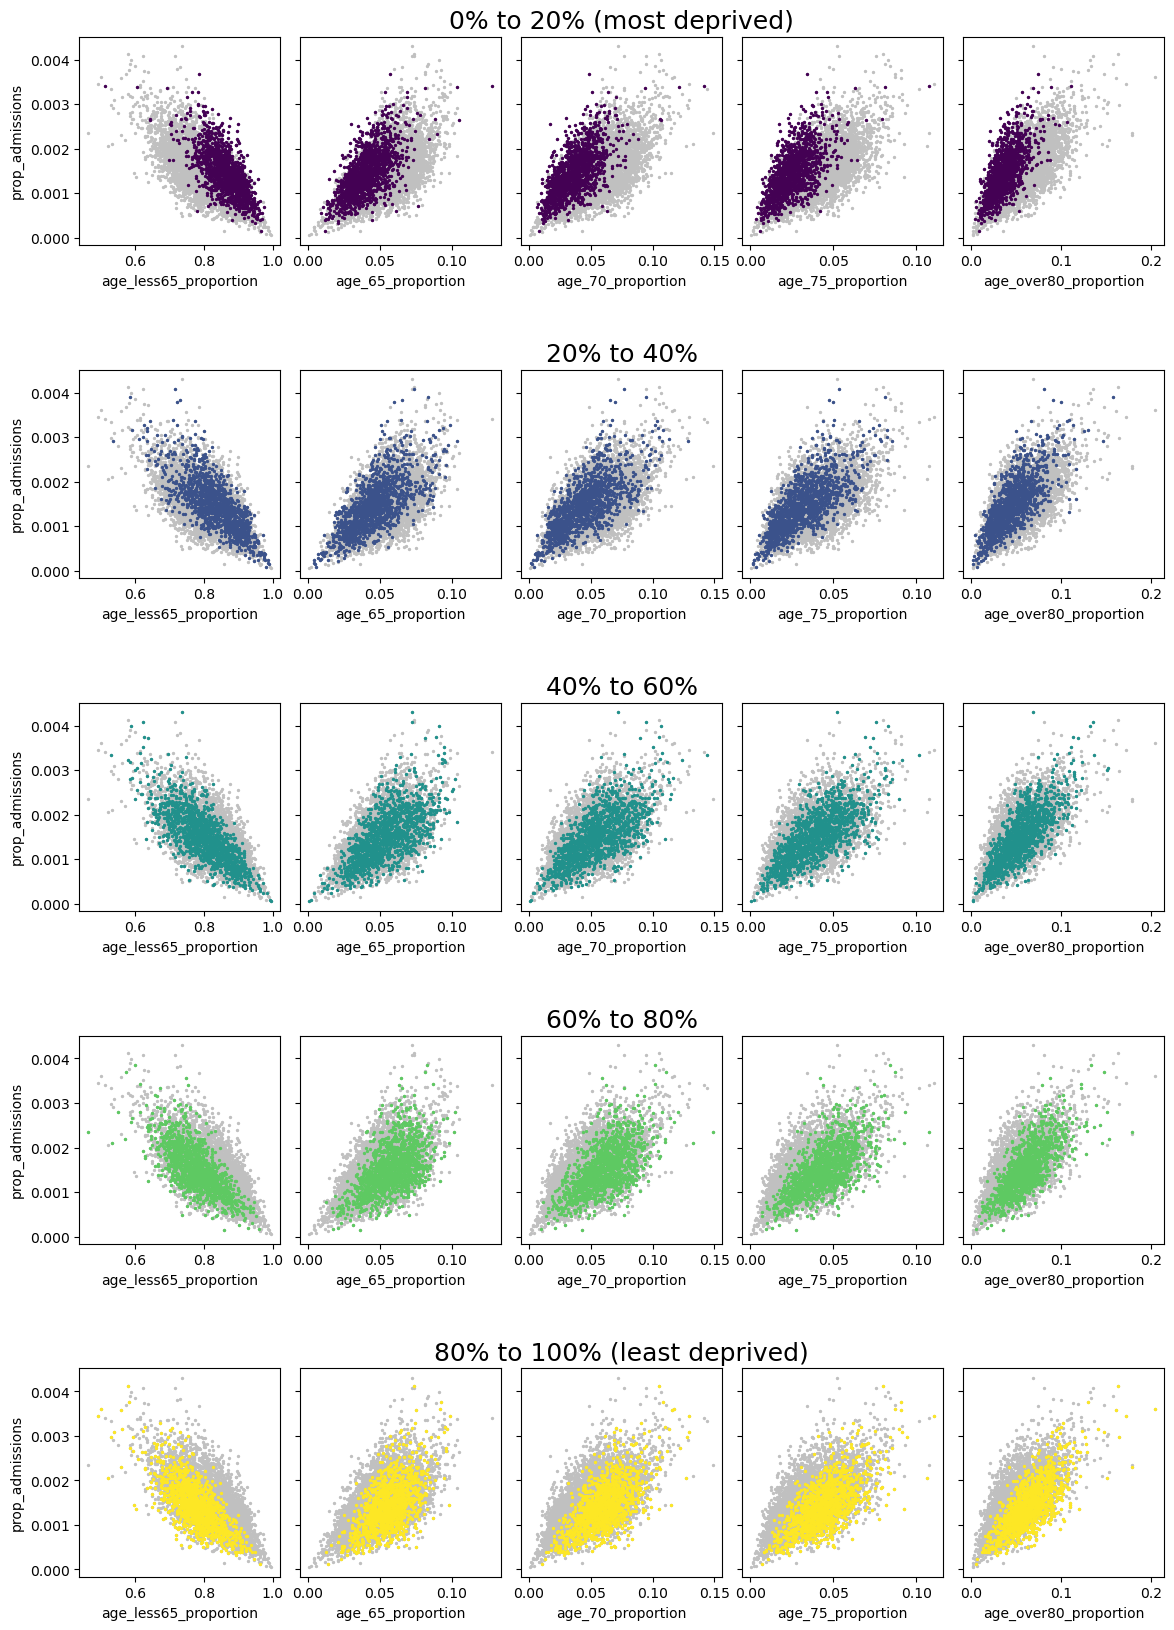

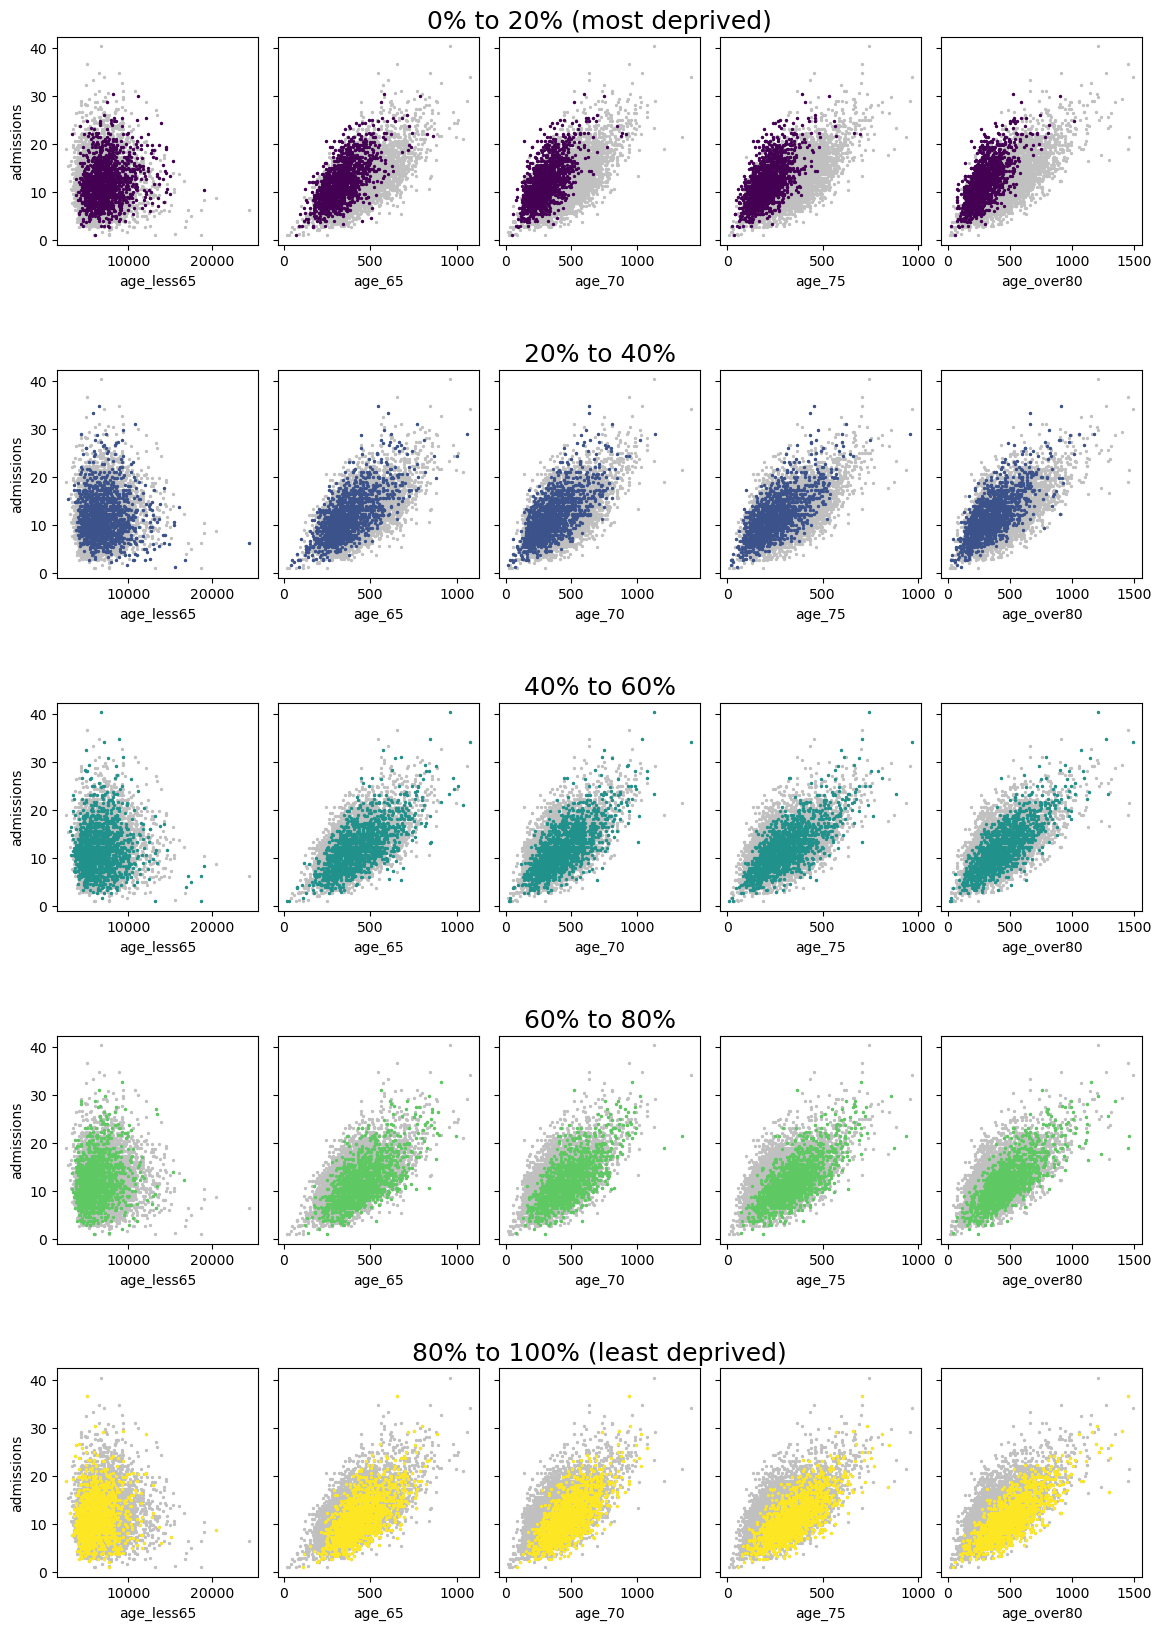

In [11]:
for py, y_col in enumerate(['prop_admissions', 'admissions']):
    path_to_image = os.path.join('images', f'scatter_age_{y_col}_by_imd.png')
    display(Image(filename=path_to_image))